In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import pandas as pd
from JobParameters import AerodynamicParameters, AcousticParameters
from Propeller import Propeller
import aerosandbox as asb

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=10, num_obs_times_per_rev=50
)

In [2]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [3]:
r_observer = np.array([[0, 1.8, 0],
                        [0, 0, 1.8]])
propeller.run_compact_f1a(observer_positions=r_observer, use_GPU=True)

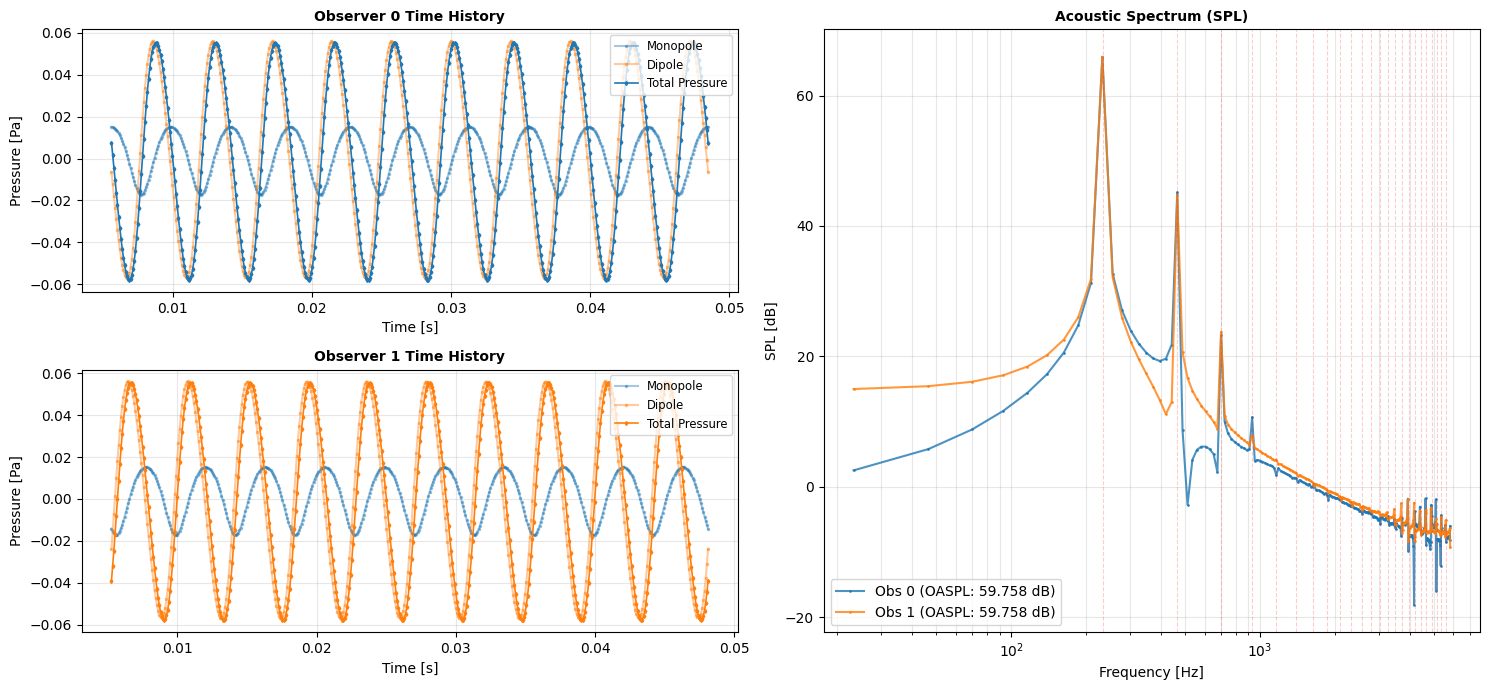

In [4]:
from Plotter import Plotter

plot = Plotter(propeller=propeller)

plot.plot_observer_report()

In [ ]:
def prandtlLoss(phi, r):
    B = aerodynamic_params.n_blades

    f_tip = B * (aerodynamic_params.prop_radius - r) / (2 * r * np.sin(phi))
    f_hub = B * (r - aerodynamic_params.hub_radius) / (2 * r * np.sin(phi))

    # Clip to avoid overflow
    f_tip = np.clip(f_tip, 0.0, 500.0)
    f_hub = np.clip(f_hub, 0.0, 500.0)

    F_tip = 2 * np.arccos(np.exp(-f_tip)) / np.pi
    F_hub = 2 * np.arccos(np.exp(-f_hub)) / np.pi

    return F_tip * F_hub

In [ ]:
from TurbulenceGenerator import TurbulenceGenerator

Ly, Lz = 0.3, 0.3     
Lx = 2 * propeller.solution_data.u.values.mean() * propeller.acoustic_params.revolutions * 60 / propeller.aero_params.rpm             

ny, nz = 100, 100
nx = int(100 * Lx)

sigma = 1  # Turbulence intensity (m/s)         
# L_scale: Set to 1/2 of diameter to see spatial variation across blades
L_scale = propeller.aero_params.prop_radius / 2       

turbulence_generator = TurbulenceGenerator(
    Lx=Lx,
    Ly=Ly,
    Lz=Lz,
    nx=nx,
    ny=ny,
    nz=nz,
    sigma=sigma,
    L_scale=L_scale,
    device='cuda',
    seed=1
)

u_box = turbulence_generator.generate_turbulence()

nx, ny, nz = u_box.shape

In [ ]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

aero_caches = [{} for _ in range(len(blade_dict['r']))]

def get_cache_key(alpha, Re, Ma):
    return (round(alpha, 3), round(Re, -4), round(Ma, 1))

x_coords = np.linspace(0, Lx, nx)
y_coords = np.linspace(-Ly/2, Ly/2, ny)
z_coords = np.linspace(-Lz/2, Lz/2, nz)
interp_u = RegularGridInterpolator((x_coords, y_coords, z_coords), u_box,
                                     bounds_error=False, fill_value=0)

In [ ]:
# --- 1. PRE-ALLOCATION ---
n_stations = len(blade_dict['r'])
n_blades = aerodynamic_params.n_blades

_tables = [{} for _ in range(n_stations)]

dt = np.diff(propeller.acoustic_params.src_times)[0]
time_steps = len(propeller.acoustic_params.src_times)
history_no_delay = {key: np.zeros((time_steps, n_blades, n_stations)) for key in 
           ['alpha', 'phi', 'W', 'cl', 'cd', 'vi', 'vt', 'dT', 'dQ', 'Re', 'Ma']}

# Global totals (1D arrays)
thrust_history = np.zeros(time_steps)
torque_history = np.zeros(time_steps)

x_accum = 0.0
modelSize = 'xxxlarge'
initial_phi = propeller.solution_data.phi.values

# --- 2. SIMULATION LOOP ---
for time_idx, t in enumerate(propeller.acoustic_params.src_times):
    n_iters = int(np.interp(time_idx, [0, 100], [5, 1]))
    # Advection

    v_advection = v_inf + np.mean(history_no_delay['vi'][time_idx-1]) if time_idx > 0 else 0
    x_accum += v_advection * dt
    x_plane = x_accum % Lx 
    
    T_ts = 0
    Q_ts = 0
    
    for b in range(n_blades):
        psi = (aerodynamic_params.omega * t) + (b * 2 * np.pi / n_blades)
        
        for i in range(n_stations):
            r = blade_dict['r'][i]
            dr = blade_dict['dr'][i]
            chord = blade_dict['chord'][i]
            omega_r = aerodynamic_params.omega * r
            
            # Sample Turbulence
            y_pos, z_pos = r * np.cos(psi), r * np.sin(psi)
            u_gust = interp_u([x_plane, y_pos, z_pos])[0]
            # if time_idx > 1000:
            #     u_gust = 5
            # Current Induction (from states)
            vQs, vT = history_no_delay['vi'][time_idx-1, b, i] if time_idx > 0 else propeller.solution_data.u.values[i], history_no_delay['vt'][time_idx-1, b, i] if time_idx > 0 else aerodynamic_params.omega * r * (1 - propeller.solution_data.a_prime.values[i])
            for iter in range(n_iters):
                # --- BEMT CALCULATIONS ---
                phi = np.arctan2(vQs, vT)
                alpha = blade_dict['twist'][i] - np.degrees(phi)
                W = np.sqrt(vQs**2 + vT**2)
                
                # Reynolds/Mach
                Re = aerodynamic_params.rho * W * chord / aerodynamic_params.mu
                Ma = W / aerodynamic_params.a_inf
                
                ReBin = round(Re, -4)
                MaBin = round(Ma, 1)
                key = (ReBin, MaBin)

                # Lazily build the CL/CD vs alpha table for this (ReBin, MaBin)
                if key not in _tables[i]:
                    # Alpha grid in degrees for tabulation
                    alpha_grid = np.linspace(-30.0, 40.0, 141)
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha_grid, Re=ReBin, mach=MaBin, model_size=modelSize)
                    cl_grid = np.asarray(full_output["CL"], dtype=float)
                    cd_grid = np.asarray(full_output["CD"], dtype=float)
                    _tables[i][key] = (alpha_grid, cl_grid, cd_grid)

                alpha_grid, cl_grid, cd_grid = _tables[i][key]
                # 1D linear interpolation in alpha (degrees)
                cL = np.interp(alpha, alpha_grid, cl_grid)
                cD = np.interp(alpha, alpha_grid, cd_grid)
                if np.isnan(cL) or np.isnan(cD):
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha, Re=Re, mach=Ma, model_size=modelSize)
                    cL, cD = full_output["CL"].item(), full_output["CD"].item()

                cLPrime = cL * np.cos(phi) - cD * np.sin(phi)
                cDPrime = cL * np.sin(phi) + cD * np.cos(phi)
                
                F = np.clip(prandtlLoss(phi, r), 1e-5, 1.0)
                sigma = aerodynamic_params.n_blades * chord / (2 * np.pi * r)
                k_t = sigma * cLPrime / (4 * F * np.sin(phi) * np.cos(phi)) 
                k_q = sigma * cDPrime / (4 * F * np.sin(phi) * np.cos(phi))
                aPrime = k_q / (1 + k_q)
                vQs_new = aerodynamic_params.omega * r * k_t / (1 + k_q) + v_inf + u_gust
                vT_new = aerodynamic_params.omega * r * (1 - aPrime)

                vQs += 0.7 * (vQs_new - vQs)
                vT += 0.7 * (vT_new - vT)
                
            # --- RECORD TO HISTORY ---
            history_no_delay['alpha'][time_idx, b, i] = alpha
            history_no_delay['phi'][time_idx, b, i]   = phi
            history_no_delay['W'][time_idx, b, i]     = W
            history_no_delay['cl'][time_idx, b, i]    = cL
            history_no_delay['cd'][time_idx, b, i]    = cD
            history_no_delay['vi'][time_idx, b, i]    = vQs
            history_no_delay['vt'][time_idx, b, i]    = vT
            history_no_delay['Re'][time_idx, b, i]    = Re
            history_no_delay['Ma'][time_idx, b, i]    = Ma

            dT = 0.5 * aerodynamic_params.rho * W**2 * chord * cLPrime * dr
            dQ = 0.5 * aerodynamic_params.rho * W**2 * chord * cDPrime * r * dr
            
            history_no_delay['dT'][time_idx, b, i] = dT
            history_no_delay['dQ'][time_idx, b, i] = dQ
            
            T_ts += dT
            Q_ts += dQ

    thrust_history[time_idx] = T_ts
    torque_history[time_idx] = Q_ts
    
    if time_idx % 100 == 0:
        print(f"Step {time_idx+1}/{len(propeller.acoustic_params.src_times)} | V_scan: {v_advection:.3f} m/s | Total T: {T_ts:.4f} N | Total Q: {Q_ts:.4f} N·m")

In [ ]:
import numpy as np

# --- 1. PRE-ALLOCATION & STATE INITIALIZATION ---
n_stations = len(blade_dict['r'])
n_blades = aerodynamic_params.n_blades
R_tip = blade_dict['r'][-1]
dt = np.diff(propeller.acoustic_params.src_times)[0]
time_steps = len(propeller.acoustic_params.src_times)

# Øye State Variables (one per blade per station)
# v_qs_prev: Quasi-steady target from the previous step (for dv/dt)
# v_int: Intermediate far-wake state
v_qs_prev = np.zeros((n_blades, n_stations))
v_int_prev = np.zeros((n_blades, n_stations))

# Initialize induction from initial solution
# We'll assume the wake starts in equilibrium
for b in range(n_blades):
    v_qs_prev[b, :] = initial_phi  # Using initial_phi as starting vI
    v_int_prev[b, :] = initial_phi

history_oye_model = {key: np.zeros((time_steps, n_blades, n_stations)) for key in 
           ['alpha', 'phi', 'W', 'cl', 'cd', 'vi', 'v_int', 'v_qs', 'vt', 'dT', 'dQ', 'Re', 'Ma']}

thrust_history = np.zeros(time_steps)
torque_history = np.zeros(time_steps)

x_accum = 0.0
modelSize = 'xxxlarge'
_tables = [{} for _ in range(n_stations)]

# --- 2. SIMULATION LOOP ---
for time_idx, t in enumerate(propeller.acoustic_params.src_times):
    n_iters = int(np.interp(time_idx, [0, 100], [5, 1]))
    # Advection calculation
    v_avg_ind = v_inf + np.mean(history_oye_model['vi'][time_idx-1]) if time_idx > 0 else 0
    x_accum += v_avg_ind * dt
    x_plane = x_accum % Lx 
    
    T_ts = 0.0
    Q_ts = 0.0
    
    for b in range(n_blades):
        psi = (aerodynamic_params.omega * t) + (b * 2 * np.pi / n_blades)
        
        for i in range(n_stations):
            r = blade_dict['r'][i]
            dr = blade_dict['dr'][i]
            chord = blade_dict['chord'][i]
            
            # Sample Turbulence
            y_pos, z_pos = r * np.cos(psi), r * np.sin(psi)
            u_gust = interp_u([x_plane, y_pos, z_pos])[0]
            # if time_idx > 1000:
            #     u_gust = 5
            # Current state values
            vQs, vT = history_oye_model['vi'][time_idx-1, b, i] if time_idx > 0 else propeller.solution_data.u.values[i], history_oye_model['vt'][time_idx-1, b, i] if time_idx > 0 else aerodynamic_params.omega * r * (1 - propeller.solution_data.a_prime.values[i])

            for iter in range(n_iters):
                # --- BEMT CALCULATIONS ---
                phi = np.arctan2(vQs, vT)
                alpha = blade_dict['twist'][i] - np.degrees(phi)
                W = np.sqrt(vQs**2 + vT**2)
                
                # Reynolds/Mach
                Re = aerodynamic_params.rho * W * chord / aerodynamic_params.mu
                Ma = W / aerodynamic_params.a_inf
                
                ReBin = round(Re, -4)
                MaBin = round(Ma, 1)
                key = (ReBin, MaBin)

                # Lazily build the CL/CD vs alpha table for this (ReBin, MaBin)
                if key not in _tables[i]:
                    # Alpha grid in degrees for tabulation
                    alpha_grid = np.linspace(-30.0, 40.0, 141)
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha_grid, Re=ReBin, mach=MaBin, model_size=modelSize)
                    cl_grid = np.asarray(full_output["CL"], dtype=float)
                    cd_grid = np.asarray(full_output["CD"], dtype=float)
                    _tables[i][key] = (alpha_grid, cl_grid, cd_grid)

                alpha_grid, cl_grid, cd_grid = _tables[i][key]
                # 1D linear interpolation in alpha (degrees)
                cL = np.interp(alpha, alpha_grid, cl_grid)
                cD = np.interp(alpha, alpha_grid, cd_grid)
                if np.isnan(cL) or np.isnan(cD):
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha, Re=Re, mach=Ma, model_size=modelSize)
                    cL, cD = full_output["CL"].item(), full_output["CD"].item()

                cLPrime = cL * np.cos(phi) - cD * np.sin(phi)
                cDPrime = cL * np.sin(phi) + cD * np.cos(phi)
                
                F = np.clip(prandtlLoss(phi, r), 1e-5, 1.0)
                sigma = aerodynamic_params.n_blades * chord / (2 * np.pi * r)
                k_t = sigma * cLPrime / (4 * F * np.sin(phi) * np.cos(phi)) 
                k_q = sigma * cDPrime / (4 * F * np.sin(phi) * np.cos(phi))
                aPrime = k_q / (1 + k_q)
                vQs_new = aerodynamic_params.omega * r * k_t / (1 + k_q) + v_inf + u_gust
                vT_new = aerodynamic_params.omega * r * (1 - aPrime)

                vQs += 0.7 * (vQs_new - vQs)
                vT += 0.7 * (vT_new - vT)

            # --- STEP B: ØYE DYNAMIC INFLOW FILTERING ---
            tau1 = 0.2*np.max(blade_dict['r'])
            tau2 = (0.39 - 0.26 * (r / R_tip)**2) * tau1
            
            # Slow filter (Intermediate)
            v_int = (history_oye_model['v_int'][time_idx-1, b, i] if time_idx > 0 else propeller.solution_data.u.values[i])*(1-dt/tau1) + 0.6*vQs + (history_oye_model['v_qs'][time_idx-1, b, i] if time_idx > 0 else propeller.solution_data.u.values[i])*(dt/tau1-0.6)
            
            # Fast filter (Final Induced Velocity)
            vI_next = (history_oye_model['vi'][time_idx-1, b, i] if time_idx > 0 else propeller.solution_data.u.values[i])*(1-dt/tau2) + v_int*dt/tau2
            
            # --- STEP C: FINAL FORCES & RECORDING ---
            # Re-calculate aero with the NEW lagged induction
            phi = np.arctan2(vI_next, vT)
            W = np.sqrt(vI_next**2 + vT**2)
            alpha = blade_dict['twist'][i] - np.degrees(phi)

            Re = aerodynamic_params.rho * W * chord / aerodynamic_params.mu
            Ma = W / aerodynamic_params.a_inf
            
            ReBin = round(Re, -4)
            MaBin = round(Ma, 1)
            key = (ReBin, MaBin)

            if key not in _tables[i]:
                # Alpha grid in degrees for tabulation
                alpha_grid = np.linspace(-30.0, 40.0, 141)
                full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha_grid, Re=ReBin, mach=MaBin, model_size=modelSize)
                cl_grid = np.asarray(full_output["CL"], dtype=float)
                cd_grid = np.asarray(full_output["CD"], dtype=float)
                _tables[i][key] = (alpha_grid, cl_grid, cd_grid)

            alpha_grid, cl_grid, cd_grid = _tables[i][key]
            cL = np.interp(alpha, alpha_grid, cl_grid)
            cD = np.interp(alpha, alpha_grid, cd_grid)
            if np.isnan(cL) or np.isnan(cD):
                full_output = asb.Airfoil.get_aero_from_neuralfoil(propeller._section_airfoils[i], alpha=alpha, Re=Re, mach=Ma, model_size=modelSize)
                cL, cD = full_output["CL"].item(), full_output["CD"].item()

            cLPrime = cL * np.cos(phi) - cD * np.sin(phi)
            cDPrime = cL * np.sin(phi) + cD * np.cos(phi)
                            
            history_oye_model['alpha'][time_idx, b, i] = alpha
            history_oye_model['phi'][time_idx, b, i]   = phi
            history_oye_model['W'][time_idx, b, i]     = W
            history_oye_model['cl'][time_idx, b, i]    = cL
            history_oye_model['cd'][time_idx, b, i]    = cD
            history_oye_model['vi'][time_idx, b, i]    = vI_next
            history_oye_model['v_int'][time_idx, b, i]    = v_int
            history_oye_model['v_qs'][time_idx, b, i]    = vQs
            history_oye_model['vt'][time_idx, b, i]    = vT
            history_oye_model['Re'][time_idx, b, i]    = Re
            history_oye_model['Ma'][time_idx, b, i]    = Ma

            dT = 0.5 * aerodynamic_params.rho * W**2 * chord * cLPrime * dr
            dQ = 0.5 * aerodynamic_params.rho * W**2 * chord * cDPrime * r * dr
            
            history_oye_model['dT'][time_idx, b, i] = dT
            history_oye_model['dQ'][time_idx, b, i] = dQ

            T_ts += dT
            Q_ts += dQ

    thrust_history[time_idx] = T_ts
    torque_history[time_idx] = Q_ts

    if time_idx % 100 == 0:
        print(f"Step {time_idx+1}/{len(propeller.acoustic_params.src_times)} | V_scan: {v_avg_ind:.3f} m/s | Total T: {T_ts:.4f} N | Total Q: {Q_ts:.4f} N·m")

In [ ]:
import matplotlib.pyplot as plt

time_axis = np.arange(time_steps) * dt

# --- 2. PLOT ---
plt.figure(figsize=(10, 5), dpi=100)

# Plot the instantaneous total thrust
plt.plot(time_axis, history_no_delay['dT'].sum(axis=(1,2)), 
         label='Thrust (Instantaneous inflow model)', 
         lw=1.5)

plt.plot(time_axis, history_oye_model['dT'].sum(axis=(1,2)), 
         label='Thrust (Oye inflow model)', 
         lw=1.5)

propeller.run_bemt(v_inf=v_inf)
plt.axhline(y=propeller.compute_total_forces()[0], color='k', linestyle='--', alpha=0.8, label=f'Static Thrust: {propeller.compute_total_forces()[0]:.3f} N')

# Formatting
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Thrust (N)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
# plt.xlim(0.008,0.009)
plt.ylim(0.8*propeller.compute_total_forces()[0], 1.2*propeller.compute_total_forces()[0])

plt.tight_layout()
plt.show()

In [ ]:
propeller.run_compact_f1a(observer_positions=r_observer, local_dT=history_no_delay['dT'], local_dQ=history_no_delay['dQ'], use_GPU=True)
t_no_delay = propeller.t.copy()
p_no_delay = propeller.p_tot.copy()
oaspl_no_delay = propeller.oaspl.copy()

propeller.run_compact_f1a(observer_positions=r_observer, local_dT=history_oye_model['dT'], local_dQ=history_oye_model['dQ'], use_GPU=True)
t_oye_model = propeller.t.copy()
p_oye_model = propeller.p_tot.copy()
oaspl_oye_model = propeller.oaspl.copy()

In [ ]:
import pickle
import numpy as np
from scipy import signal
from OASPL import calculate_OASPL
from scipy import signal

# --- Constants & Setup ---
p_ref = 2e-5
delta_f = 10 
fontsize = 10

def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels']['1']['time']
    p = data['sound']['channels']['1']['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# 1. Load data
t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-21-17_RPM_7000.pkl')
t_motor, p_motor, fs_motor = load_data('../Datasets/Measurements/Background_2024-11-28-12-56-35_RPM_7000.pkl')

# 2. Safety Check: Verify sample rates match
if not np.isclose(fs_total, fs_motor, rtol=1e-5):
    raise ValueError(f"Sample rates do not match! Total: {fs_total:.2f} Hz, Motor: {fs_motor:.2f} Hz")

fs = fs_total 

# 3. Short-Time Fourier Transform
# We use a Hann window and a segment length of 1024 (standard for audio)
nperseg = 1024
f, t_segments, Zxx_total = signal.stft(p_total, fs=fs, nperseg=nperseg)
_, _, Zxx_motor = signal.stft(p_motor, fs=fs, nperseg=nperseg)

# 4. Spectral Subtraction Logic
# Magnitude and Phase of the Propeller + Motor signal
mag_total = np.abs(Zxx_total)
phase_total = np.angle(Zxx_total)

# Use the average power of the motor noise to create a noise profile
mag_motor_avg = np.mean(np.abs(Zxx_motor), axis=1, keepdims=True)

# Subtraction parameters
alpha = 3  # Over-subtraction factor (adjust 1.0 - 3.0)
beta = 0.1  # Noise floor (prevents completely silent/dead bins)

# Magnitude Subtraction: Mag_clean = Mag_total - alpha * Mag_motor
mag_prop = mag_total - (alpha * mag_motor_avg)

# Apply the floor (beta) where the subtraction goes below the threshold
mag_prop = np.maximum(mag_prop, beta * mag_motor_avg)

# 5. Inverse STFT to get back to Time Domain
Zxx_prop = mag_prop * np.exp(1j * phase_total)
t_final, p_prop_only = signal.istft(Zxx_prop, fs=fs)

print(f"Processing complete at {fs:.2f} Hz.")

In [ ]:
# Ensure lengths match
n = min(len(p_total), len(p_motor))
t_total, t_motor = t_total[:n], t_motor[:n]
p_total, p_motor = p_total[:n], p_motor[:n]

# 2. Perform Subtraction (Briefly re-calculated here for the plot)
f_stft, t_stft, Z_total = signal.stft(p_total, fs=fs, nperseg=2048)
_, _, Z_motor = signal.stft(p_motor, fs=fs, nperseg=2048)
mag_motor_avg = np.mean(np.abs(Z_motor), axis=1, keepdims=True)
mag_prop = np.maximum(np.abs(Z_total) - 2.0 * mag_motor_avg, 0.01 * mag_motor_avg)
t_prop_only, p_prop_only = signal.istft(mag_prop * np.exp(1j * np.angle(Z_total)), fs=fs)

# 3. Calculate OASPL (dBA)
oaspl_total = calculate_OASPL(t_total, p_total, propeller.acoustic_params.p_ref)
oaspl_motor = calculate_OASPL(t_motor, p_motor, propeller.acoustic_params.p_ref)
oaspl_prop = calculate_OASPL(t_prop_only, p_prop_only, propeller.acoustic_params.p_ref)

# 4. Plotting
fig, ax_spl = plt.subplots(figsize=(15, 6))

def plot_psd(ax, p_sig, fs, label_name, dba_val, color):
    # nperseg=fs/delta_f ensures we hit your 5Hz resolution target
    f_psd, pxx = signal.welch(p_sig, fs, window='hann', nperseg=int(fs/delta_f), scaling='density')
    psd_db = 10 * np.log10(pxx / (p_ref**2))
    ax.semilogx(f_psd, psd_db, label=f'{label_name} ({dba_val:.1f} dBA)', color=color, alpha=0.8)

plot_psd(ax_spl, p_total, fs, 'Total (Prop + Motor)', oaspl_total, 'tab:blue')
plot_psd(ax_spl, p_motor, fs, 'Motor Noise (Background)', oaspl_motor, 'tab:gray')
plot_psd(ax_spl, p_prop_only, fs, 'Propeller Only (Subtracted)', oaspl_prop, 'tab:green')

# BPF Harmonics (RPM 7000, assuming 2 blades)
bpf = (7000 / 60) * 2
for h in np.arange(bpf, 10000, bpf):
    ax_spl.axvline(h, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

# Styling
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('PSD [dB/Hz]', fontsize=fontsize)
ax_spl.set_xlim(20, 10000)
ax_spl.set_ylim(-40, 80)
ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='upper right')
plt.title('Acoustic Spectrum Comparison: RPM 7000', fontsize=fontsize+2)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import signal

delta_f = 10
fontsize = 10

# --- Calculate dBA Values ---
# Exp
fs_exp = 1 / (t_prop_only[1] - t_prop_only[0])

# F1A No Turb
fs_nt = 1 / (t_no_turb[1, 0] - t_no_turb[0, 0])

# F1A
fs_f1a = 1 / (propeller.t[1, 0] - propeller.t[0, 0])

# --- Plotting ---
fig, ax_spl = plt.subplots(figsize=(15, 6))

# Helper to plot PSD
def plot_psd(ax, p_sig, fs, label_name, dba_val):
    f_psd, pxx = signal.welch(p_sig, fs, window='hann', nperseg=fs/delta_f, scaling='density')
    psd_db = 10 * np.log10(pxx / (propeller.acoustic_params.p_ref**2))
    ax.semilogx(f_psd, psd_db, label=f'{label_name} ({dba_val:.1f} dBA)', alpha=0.8)

plot_psd(ax_spl, p_prop_only, fs_exp, 'Exp', oaspl_prop)
plot_psd(ax_spl, p_no_turb[:, 0], fs_nt, 'No Turb', oaspl_no_turb[0])
plot_psd(ax_spl, p_no_delay[:, 0], fs_nt, 'Instanenous Inflow', oaspl_no_delay[0])
plot_psd(ax_spl, p_oye_model[:, 0], fs_nt, 'Oye Model', oaspl_oye_model[0])

# Formatting
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('PSD [dB/Hz]', fontsize=fontsize)

# BPF Harmonics
bpf = 1 / acoustic_params.blade_passing_period
for h in np.arange(bpf, 10000, bpf):
    ax_spl.axvline(h, color='red', linestyle='--', linewidth=0.8, alpha=0.3)

ax_spl.set_xlim(10, 10000)
ax_spl.set_ylim(-50, 80)
ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.io import wavfile
import numpy as np

# 1. Ensure the data is 1D (monaural)
audio_data = p_prop_only.flatten()

# 2. Normalize to prevent clipping and convert to 16-bit PCM
# This scales the audio to fit between -1.0 and 1.0, then maps to int16
if np.max(np.abs(audio_data)) > 0:
    audio_data = audio_data / np.max(np.abs(audio_data))

audio_int16 = (audio_data * 32767).astype(np.int16)

# 3. Write to file
wavfile.write('prop_only.wav', int(fs), audio_int16)

In [ ]:
# 1. Ensure the data is 1D (monaural)
audio_data = p_no_turb.flatten()

# 2. Normalize to prevent clipping and convert to 16-bit PCM
# This scales the audio to fit between -1.0 and 1.0, then maps to int16
if np.max(np.abs(audio_data)) > 0:
    audio_data = audio_data / np.max(np.abs(audio_data))

audio_int16 = (audio_data * 32767).astype(np.int16)

# 3. Write to file
wavfile.write('p_no_turb.wav', int(fs), audio_int16)